<a href="https://colab.research.google.com/github/Aleem-mja/DeepLearning-Project-SLIIT-SE4050/blob/IT22313966/IMDB_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [61]:
# -------------------------------
# 1) Imports, seeds, and globals
# -------------------------------
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix # Added confusion_matrix
import matplotlib.pyplot as plt
import os

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Hyperparameters / globals
MAX_FEATURES = 10000   # number of words to keep (most frequent)
MAXLEN = 500           # cut texts after this number of words (among top MAX_FEATURES)
EMBED_DIM = 128
RNN_UNITS = 64
BATCH_SIZE = 128
EPOCHS = 10
VAL_SAMPLES = 5000     # size of validation set taken from training set
MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

In [62]:
# -----------------------------------------
# 2) Data loading and preprocessing (Keras)
# -----------------------------------------
print("Loading IMDB dataset (integer-encoded reviews)...")
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=MAX_FEATURES)

# Pad sequences so all inputs have the same length
x_train = pad_sequences(x_train, maxlen=MAXLEN)
x_test  = pad_sequences(x_test,  maxlen=MAXLEN)

print("Shapes after padding:")
print(f"  x_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"  x_test:  {x_test.shape},  y_test:  {y_test.shape}")

# Create validation set from the end of training set
x_val = x_train[-VAL_SAMPLES:]
y_val = y_train[-VAL_SAMPLES:]
x_train = x_train[:-VAL_SAMPLES]
y_train = y_train[:-VAL_SAMPLES]

print("Shapes after creating validation set:")
print(f"  x_train: {x_train.shape}, x_val: {x_val.shape}, x_test: {x_test.shape}")


Loading IMDB dataset (integer-encoded reviews)...
Shapes after padding:
  x_train: (25000, 500), y_train: (25000,)
  x_test:  (25000, 500),  y_test:  (25000,)
Shapes after creating validation set:
  x_train: (20000, 500), x_val: (5000, 500), x_test: (25000, 500)


In [63]:
# -----------------------------------------
# 3) Model building (function for reuse)
# -----------------------------------------
def build_rnn_model(max_features=MAX_FEATURES, embed_dim=EMBED_DIM, rnn_units=RNN_UNITS, maxlen=MAXLEN, dropout_rate=0.5):
    """
    Build and return a Sequential RNN model:
      Embedding -> SimpleRNN -> SimpleRNN -> Dropout -> Dense(sigmoid)
    """
    model = Sequential([
        Embedding(max_features, embed_dim, input_length=maxlen),
        SimpleRNN(rnn_units, return_sequences=True),
        SimpleRNN(rnn_units),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')
    ])
    return model

# Build and compile
print("Building model...")
model = build_rnn_model()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Building model...


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [64]:
# ---------------------------
# 4) Train the model
# ---------------------------
print("Training the model...")
history = model.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val, y_val),
    verbose=1
)

# Save the trained model for later use
model_path = os.path.join(MODEL_DIR, "imdb_rnn_model.h5")
model.save(model_path)
print(f"Saved model to: {model_path}")


Training the model...
Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 89s 545ms/step - accuracy: 0.5994 - loss: 0.6488 - val_accuracy: 0.8130 - val_loss: 0.4169
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 144s 560ms/step - accuracy: 0.8170 - loss: 0.4114 - val_accuracy: 0.8110 - val_loss: 0.4538
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 138s 537ms/step - accuracy: 0.9085 - loss: 0.2454 - val_accuracy: 0.8270 - val_loss: 0.4679
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 87s 555ms/step - accuracy: 0.9457 - loss: 0.1490 - val_accuracy: 0.7190 - val_loss: 0.7814
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 91s 582ms/step - accuracy: 0.9739 - loss: 0.0748 - val_accuracy: 0.7574 - val_loss: 0.7266
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 134s 532ms/step - accuracy: 0.9866 - loss: 0.0428 - val_accuracy: 0.8040 - val_loss: 0.7767
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 150s 586ms/step - accuracy: 0.9904 - loss: 0.0304 - val_accuracy: 0.7808 - val_loss: 0.9557
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 133s 531ms/step -

Saved model to: models/imdb_rnn_model.h5


In [65]:
# -----------------------------------
# 5) Evaluate on test data & metrics
# -----------------------------------
print("Predicting on test set...")
y_pred_prob = model.predict(x_test, batch_size=BATCH_SIZE)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print(f"Test Accuracy : {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall   : {recall:.4f}")
print(f"Test F1 Score : {f1:.4f}")


Predicting on test set...
196/196 ━━━━━━━━━━━━━━━━━━━━ 27s 138ms/step
Test Accuracy : 0.7884
Test Precision: 0.7784
Test Recall   : 0.8064
Test F1 Score : 0.7921


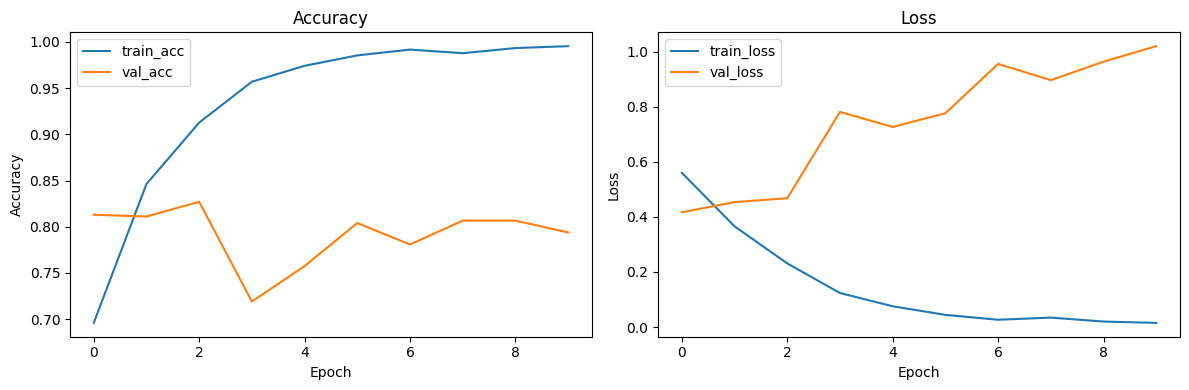

In [66]:
# -----------------------------------
# 6) Plot training & validation curves
# -----------------------------------
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


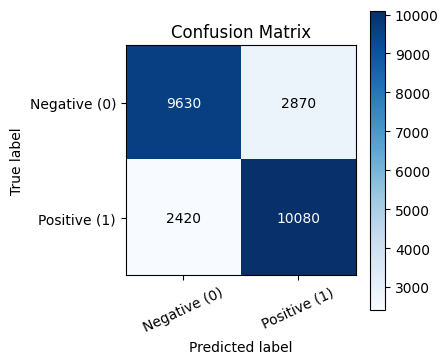

In [67]:
# -----------------------------------
# 7) Confusion matrix (matplotlib)
# -----------------------------------
cm = confusion_matrix(y_test, y_pred)
classes = ['Negative (0)', 'Positive (1)']

plt.figure(figsize=(4.5,4))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues) # Added cmap for better visualization
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=25)
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

In [68]:
# ------------------------------------------------
# 8) Inference: raw text -> sentiment prediction
# ------------------------------------------------
word_index = imdb.get_word_index()  # word -> idx (without special tokens)
INDEX_OFFSET = 3  # 0=<PAD>, 1=<START>, 2=<UNK> are reserved

def text_to_sequence(text, maxlen=MAXLEN):
    # super-simple whitespace tokenizer; you can improve later
    tokens = text.lower().split()
    seq = []
    for w in tokens:
        idx = word_index.get(w)
        if idx is not None:
            seq.append(idx + INDEX_OFFSET)
        else:
            seq.append(2)  # <UNK>
    return pad_sequences([seq], maxlen=maxlen)

def predict_sentiment(text, model=model):
    seq = text_to_sequence(text)
    prob = float(model.predict(seq)[0][0])
    label = "Positive" if prob > 0.5 else "Negative"
    return {"label": label, "probability": prob}



In [69]:
# Testing the model example Reviews
example_review = "This movie was fantastic!"
print("Example prediction:", predict_sentiment(example_review))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Example prediction: {'label': 'Positive', 'probability': 0.9981580376625061}
